# **Perbandingan Akurasi Model Linear Regression dan Support Vector Regression dalam Tren Perceraian di Indonesia: Studi Kasus Data 2018, 2019, 2020, dan 2021**

## **Pendahuluan**

Dataset ini berisi data jumlah perceraian yang dikumpulkan dari Badan Pusat Statistik (BPS) Nasional, mencakup periode tahun 2018, 2019, 2020, dan 2021. Data ini mencakup informasi jumlah perceraian di berbagai provinsi di Indonesia dan faktor-faktor yang berkontribusi terhadap perceraian tersebut.

Faktor-faktor yang mempengaruhi perceraian dalam dataset ini meliputi berbagai alasan seperti ekonomi, sosial, dan budaya. Nama-nama kolom yang digunakan dalam dataset ini meliputi:
*   Provinsi
*   Fakor Perceraian - Zina
*   Fakor Perceraian - Mabuk
*   Fakor Perceraian - Madat
*   Fakor Perceraian - Judi
*   Fakor Perceraian - Meninggalkan Salah satu Pihak
*   Fakor Perceraian - Dihukum Penjara
*   Fakor Perceraian - Poligami
*   Fakor Perceraian - Kekerasan Dalam Rumah Tangga
*   Fakor Perceraian - Cacat Badan
*   Fakor Perceraian - Perselisihan dan Pertengkaran Terus Menerus
*   Fakor Perceraian - Kawin Paksa
*   Fakor Perceraian - Murtad
*   Fakor Perceraian - Ekonomi
*   Fakor Perceraian - Lain-lain
*   Fakor Perceraian - Jumlah

Tujuan utama dari penggunaan dataset ini adalah untuk melakukan analisis deskriptif dan prediktif guna mengidentifikasi faktor-faktor dominan yang mempengaruhi perceraian. Dengan memanfaatkan model Linear Regression dan Random Forest Regressor

### **Akses drive dan import library awal**


Bagian awal ini kita mengakses Google Drive pada lingkungan Google Colab, yang memungkinkan pengguna untuk menyimpan dan memproses file langsung dari Drive. Dilanjutkan dengan perintah shell `!mkdir -p` untuk membuat direktori spesifik di dalam Google Drive.

Pada bagian ini kita juga melakukan import beberapa library Python seperti `pandas as pd` untuk membaca, memproses, dan menganalisis data kemudian `numpy as np` untuk komputasi numerik, `matplotlib.pyplot as plt` untuk visualisasi data, `seaborn as sns`  untuk membuat visualisasi data yang lebih informatif.

In [ ]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

# Pastikan direktori yang dituju benar-benar ada
!mkdir -p "/content/drive/My Drive/Colab Notebooks/tutorial/bigdata/forecasting"

# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


Mounted at /content/drive


Bagian ini digunakan untuk membaca beberapa file CSV yang berisi data perceraian dan mengganti nama kolom agar lebih mudah dibaca

In [ ]:
# Path file CSV untuk setiap tahun
data_paths = {
    "data_2018": "/content/drive/My Drive/Colab Notebooks/tutorial/bigdata/forecasting/Jumlah Perceraian Menurut Provinsi dan Faktor, 2018.csv",
    "data_2019": "/content/drive/My Drive/Colab Notebooks/tutorial/bigdata/forecasting/Jumlah Perceraian Menurut Provinsi dan Faktor, 2019.csv",
    "data_2020": "/content/drive/My Drive/Colab Notebooks/tutorial/bigdata/forecasting/Jumlah Perceraian Menurut Provinsi dan Faktor, 2020.csv",
    "data_2021": "/content/drive/My Drive/Colab Notebooks/tutorial/bigdata/forecasting/Jumlah Perceraian Menurut Provinsi dan Faktor, 2021.csv"
}

# Kolom yang akan di-rename untuk setiap dataset
rename_columns = {
    "Provinsi": "Provinsi",
    "Fakor Perceraian - Zina": "Zina",
    "Fakor Perceraian - Mabuk": "Mabuk",
    "Fakor Perceraian - Madat": "Madat",
    "Fakor Perceraian - Judi": "Judi",
    "Fakor Perceraian - Meninggalkan Salah satu Pihak": "Tinggalkan_Pihak",
    "Fakor Perceraian - Dihukum Penjara": "Penjara",
    "Fakor Perceraian - Poligami": "Poligami",
    "Fakor Perceraian - Kekerasan Dalam Rumah Tangga": "KDRT",
    "Fakor Perceraian - Cacat Badan": "Cacat",
    "Fakor Perceraian - Perselisihan dan Pertengkaran Terus Menerus": "Pertengkaran",
    "Fakor Perceraian - Kawin Paksa": "Kawin_Paksa",
    "Fakor Perceraian - Murtad": "Murtad",
    "Fakor Perceraian - Ekonomi": "Ekonomi",
    "Fakor Perceraian - Lain-lain": "Lain_lain",
    "Fakor Perceraian - Jumlah": "Jumlah"
}


# Membaca dan menampilkan data untuk setiap tahun
data_frames = {}

for year_key, path in data_paths.items():
    data = pd.read_csv(path)
    data = data.rename(columns=rename_columns)
    data_frames[year_key] = data  # Menyimpan DataFrame di dictionary
    print(f"Data untuk {year_key.split('_')[1]}:")
    display(data.head())


Data untuk 2018:


,Provinsi,Zina,Mabuk,Madat,Judi,Tinggalkan_Pihak,Penjara,Poligami,KDRT,Cacat,Pertengkaran,Kawin_Paksa,Murtad,Ekonomi,Lain_lain,Jumlah
0,Aceh,1.0,15.0,19.0,10.0,968.0,44.0,17.0,107.0,8.0,3426.0,1.0,2.0,485.0,92.0,5195.0
1,Sumatera Utara,209.0,198.0,508.0,194.0,2551.0,109.0,7.0,159.0,4.0,7235.0,10.0,21.0,1623.0,336.0,13164.0
2,Sumatera Barat,12.0,9.0,7.0,44.0,1428.0,35.0,18.0,147.0,20.0,4868.0,15.0,5.0,735.0,NaN,7343.0
3,Riau,24.0,62.0,17.0,58.0,1676.0,50.0,16.0,208.0,32.0,6926.0,21.0,18.0,1516.0,NaN,10624.0
4,Jambi,4.0,34.0,8.0,29.0,711.0,29.0,9.0,102.0,3.0,2874.0,1.0,3.0,462.0,NaN,4269.0


Data untuk 2019:


,Provinsi,Zina,Mabuk,Madat,Judi,Tinggalkan_Pihak,Penjara,Poligami,KDRT,Cacat,Pertengkaran,Kawin_Paksa,Murtad,Ekonomi,Lain_lain,Jumlah
0,Aceh,2.0,9,5.0,4.0,1123,58.0,27.0,107,15.0,4221,2.0,5,416,69.0,6063
1,Sumatera Utara,106.0,82,218.0,110.0,2177,96.0,6.0,110,8.0,11670,NaN,42,701,179.0,15505
2,Sumatera Barat,4.0,12,13.0,33.0,1518,42.0,24.0,133,5.0,6396,9.0,6,459,NaN,8654
3,Riau,1.0,17,11.0,33.0,1238,64.0,6.0,115,4.0,7608,6.0,10,635,NaN,9748
4,Jambi,3.0,12,13.0,17.0,743,26.0,11.0,69,2.0,3254,3.0,6,489,NaN,4648


Data untuk 2020:


,Provinsi,Zina,Mabuk,Madat,Judi,Tinggalkan_Pihak,Penjara,Poligami,KDRT,Cacat,Pertengkaran,Kawin_Paksa,Murtad,Ekonomi,Lain_lain,Jumlah
0,Aceh,1.0,4.0,18.0,11.0,699.0,90.0,19.0,88.0,27.0,5238.0,3.0,9.0,235.0,NaN,6442.0
1,Sumatera Utara,1.0,6.0,24.0,12.0,1587.0,67.0,14.0,37.0,3.0,15244.0,1.0,73.0,201.0,NaN,17270.0
2,Sumatera Barat,3.0,4.0,2.0,15.0,883.0,39.0,10.0,29.0,6.0,8172.0,3.0,14.0,191.0,NaN,9371.0
3,Riau,39.0,35.0,24.0,33.0,1303.0,106.0,33.0,131.0,10.0,10285.0,10.0,37.0,676.0,NaN,12722.0
4,Jambi,3.0,14.0,4.0,14.0,448.0,29.0,13.0,36.0,2.0,4140.0,NaN,11.0,286.0,NaN,5000.0


Data untuk 2021:


,Provinsi,Zina,Mabuk,Madat,Judi,Tinggalkan_Pihak,Penjara,Poligami,KDRT,Cacat,Pertengkaran,Kawin_Paksa,Murtad,Ekonomi,Lain_lain,Jumlah
0,Aceh,5.0,15.0,20.0,27.0,747.0,101.0,57.0,173.0,25.0,5412.0,2.0,12.0,308.0,NaN,6904.0
1,Sumatera Utara,11.0,7.0,82.0,44.0,1600.0,70.0,14.0,73.0,2.0,14980.0,2.0,91.0,357.0,NaN,17333.0
2,Sumatera Barat,2.0,9.0,7.0,19.0,754.0,31.0,10.0,33.0,4.0,7863.0,NaN,11.0,224.0,NaN,8967.0
3,Riau,24.0,28.0,34.0,33.0,962.0,118.0,28.0,134.0,4.0,9789.0,7.0,32.0,574.0,NaN,11767.0
4,Jambi,4.0,14.0,6.0,15.0,656.0,32.0,7.0,42.0,5.0,4917.0,1.0,24.0,481.0,NaN,6204.0


## **Cleaning Data**

Bagian ini kita mulai menganalisis semua data sebelum dilanjutakan dengan visualisasi data serta diproses dengan Linear Regression dan Random Forest. Pada tahap awal dimulai dengan memeriksa semua dataset yang ada kemudian ditampilkan untuk melihat jumlah data **null** yang ada pada tiap kolom yang ada pada dataset. Data Cleaning berupa identifikasi dan perbaikan kesalahan atau ketidakkonsistenan dalam dataset. Biasanya berfokus pada penanganan data yang tidak valid, hilang, atau duplikat.

In [ ]:
# Memeriksa data null untuk setiap tahun
for year_key, data in data_frames.items():
    year = year_key.split('_')[1]  # Ambil tahun langsung dari year_key
    print(f"Data Null untuk tahun {year}:")
    display(data.isnull().sum())  # Menampilkan jumlah nilai null di setiap kolom
    print("\n")

Data Null untuk tahun 2018:


,0
Provinsi,0
Zina,6
Mabuk,5
Madat,8
Judi,5
Tinggalkan_Pihak,5
Penjara,6
Poligami,5
KDRT,5
Cacat,8




Data Null untuk tahun 2019:


,0
Provinsi,0
Zina,3
Mabuk,0
Madat,2
Judi,4
Tinggalkan_Pihak,0
Penjara,1
Poligami,1
KDRT,0
Cacat,7




Data Null untuk tahun 2020:


,0
Provinsi,1
Zina,12
Mabuk,9
Madat,12
Judi,9
Tinggalkan_Pihak,8
Penjara,8
Poligami,10
KDRT,8
Cacat,12




Data Null untuk tahun 2021:


,0
Provinsi,1
Zina,13
Mabuk,8
Madat,12
Judi,8
Tinggalkan_Pihak,8
Penjara,9
Poligami,8
KDRT,8
Cacat,13


Bagian ini dilakukan pengisian data yang bernilai **null** dengan nilai `mean`.

In [ ]:
for year_key, data in data_frames.items():
    # Pilih hanya kolom numerik
    numeric_cols = data.select_dtypes(include=[np.number]).columns

    # Hitung mean dengan pembulatan dua angka di belakang koma dan isi nilai null
    data[numeric_cols] = data[numeric_cols].apply(lambda x: x.fillna(round(x.mean(), 2)))

    # Pastikan semua kolom numerik hanya memiliki dua angka di belakang koma
    data[numeric_cols] = data[numeric_cols].round(2)

    # Menghapus kolom 'Lain_lain'
    if 'Lain_lain' in data.columns:
        data.drop(columns=['Lain_lain'], inplace=True)

    # Menghapus kolom 'Jumlah'
    if 'Jumlah' in data.columns:
        data.drop(columns=['Jumlah'], inplace=True)

    # Menampilkan hasil setelah pengisian mean dan penghapusan kolom
    year = year_key.split('_')[1]  # Ambil tahun langsung dari year_key
    print(f"Data null untuk tahun {year} setelah pengisian mean:")
    display(data.isnull().sum())  # Periksa ulang apakah masih ada nilai null
    print("\n")


Data null untuk tahun 2018 setelah pengisian mean:


,0
Provinsi,0
Zina,0
Mabuk,0
Madat,0
Judi,0
Tinggalkan_Pihak,0
Penjara,0
Poligami,0
KDRT,0
Cacat,0




Data null untuk tahun 2019 setelah pengisian mean:


,0
Provinsi,0
Zina,0
Mabuk,0
Madat,0
Judi,0
Tinggalkan_Pihak,0
Penjara,0
Poligami,0
KDRT,0
Cacat,0




Data null untuk tahun 2020 setelah pengisian mean:


,0
Provinsi,1
Zina,0
Mabuk,0
Madat,0
Judi,0
Tinggalkan_Pihak,0
Penjara,0
Poligami,0
KDRT,0
Cacat,0




Data null untuk tahun 2021 setelah pengisian mean:


,0
Provinsi,1
Zina,0
Mabuk,0
Madat,0
Judi,0
Tinggalkan_Pihak,0
Penjara,0
Poligami,0
KDRT,0
Cacat,0


## **Menggabungkan Semua Dataset**

Setelah proses pembersihan data selesai, langkah berikutnya yang penting adalah menggabungkan dataset dari berbagai tahun menjadi satu dataset komprehensif. Penggabungan ini bertujuan untuk memudahkan analisis tren jangka panjang dalam jumlah perceraian serta melihat hubungan antara faktor-faktor yang mempengaruhinya di seluruh provinsi. Selain itu, menggabungkan data dari berbagai tahun memungkinkan analisis korelasi menyeluruh. Dengan memiliki semua data dalam satu set, pembuatan satu visualisasi heatmap yang mencakup semua variabel menjadi lebih mudah. Heatmap ini membantu dalam memvisualisasikan korelasi antar kolom yang ada.

Pada code dibawah ini diperlihatkan bagaimana cara menggabungkan semua dataset yang sebelumnya terpisah serta menyimpan data kedalam drive

In [ ]:
# Menggabungkan semua dataset setelah pembersihan
all_data = pd.concat(data_frames.values(), ignore_index=True)

# Menampilkan beberapa baris pertama dari data gabungan
display(all_data)

all_data.to_csv("/content/drive/My Drive/Colab Notebooks/tutorial/bigdata/forecasting/data_percerai.csv", index=False)

,Provinsi,Zina,Mabuk,Madat,Judi,Tinggalkan_Pihak,Penjara,Poligami,KDRT,Cacat,Pertengkaran,Kawin_Paksa,Murtad,Ekonomi
0,Aceh,1.0,15.00,19.00,10.0,968.00,44.00,17.00,107.00,8.00,3426.0,1.00,2.0,485.00
1,Sumatera Utara,209.0,198.00,508.00,194.0,2551.00,109.00,7.00,159.00,4.00,7235.0,10.00,21.0,1623.00
2,Sumatera Barat,12.0,9.00,7.00,44.0,1428.00,35.00,18.00,147.00,20.00,4868.0,15.00,5.0,735.00
3,Riau,24.0,62.00,17.00,58.0,1676.00,50.00,16.00,208.00,32.00,6926.0,21.00,18.0,1516.00
4,Jambi,4.0,34.00,8.00,29.0,711.00,29.00,9.00,102.00,3.00,2874.0,1.00,3.0,462.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
141,Papua,8.0,29.00,29.46,10.0,243.00,6.00,3.00,46.00,1.00,1277.0,3.00,21.0,151.00
142,Indonesia,690.0,1781.00,383.00,1191.0,39359.00,1447.00,874.00,4972.00,309.00,284169.0,377.00,1635.0,110939.00
143,NaN,55.2,118.73,29.46,79.4,2623.93,99.79,58.27,331.47,24.72,18944.6,30.16,109.0,7395.93
144,Catatan,55.2,118.73,29.46,79.4,2623.93,99.79,58.27,331.47,24.72,18944.6,30.16,109.0,7395.93


##  **Preprocessing Data**

Preprocessing data adalah langkah awal yang penting dalam analisis data untuk mempersiapkan data mentah menjadi format yang dapat diproses oleh model dan analisis lebih lanjut. Proses ini mencakup berbagai aktivitas yang bertujuan meningkatkan kualitas data agar hasil analisis dan prediksi lebih akurat dan bermakna. Data Preprocessing juga transformasi lain yang membantu data agar sesuai dengan kebutuhan model.

Fungsi `info()` digunakan untuk menampilkan informasi umum tentang DataFrame. Ini mencakup jumlah baris dan kolom, tipe data dari setiap kolom, serta jumlah nilai non-null (tidak kosong) dalam setiap kolom.

In [ ]:
all_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 146 entries, 0 to 145
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Provinsi          144 non-null    object 
 1   Zina              146 non-null    float64
 2   Mabuk             146 non-null    float64
 3   Madat             146 non-null    float64
 4   Judi              146 non-null    float64
 5   Tinggalkan_Pihak  146 non-null    float64
 6   Penjara           146 non-null    float64
 7   Poligami          146 non-null    float64
 8   KDRT              146 non-null    float64
 9   Cacat             146 non-null    float64
 10  Pertengkaran      146 non-null    float64
 11  Kawin_Paksa       146 non-null    float64
 12  Murtad            146 non-null    float64
 13  Ekonomi           146 non-null    float64
dtypes: float64(13), object(1)
memory usage: 16.1+ KB


Fungsi `describe()` memberikan statistik deskriptif untuk kolom numerik dalam DataFrame, seperti jumlah data, rata-rata, standar deviasi, nilai minimum, maksimum, dan persentil (25%, 50%, 75%).

In [ ]:
print(all_data.describe())

              Zina        Mabuk        Madat         Judi  Tinggalkan_Pihak  \
count   146.000000   146.000000   146.000000   146.000000        146.000000   
mean     61.773973   156.246918    50.399726   103.170959       3391.919110   
std     176.369444   415.999791   140.131923   270.692218       9204.715016   
min       1.000000     4.000000     1.000000     1.000000         72.000000   
25%       4.000000    19.500000     5.000000    10.250000        452.500000   
50%      12.500000    65.500000    20.000000    33.000000        943.000000   
75%      51.750000   122.922500    29.460000    79.400000       2623.930000   
max    1470.000000  3468.000000  1171.000000  2163.000000      71623.000000   

           Penjara     Poligami         KDRT       Cacat   Pertengkaran  \
count   146.000000   146.000000   146.000000  146.000000     146.000000   
mean    120.852329    69.876370   416.300753   33.750274   15877.784315   
std     401.811089   179.029562  1120.244750   84.831944   4067

In [ ]:
# Menampilkan baris berapa saja memiliki nilai null
cek_null = all_data[all_data.isnull().any(axis=1)]
print(cek_null)

    Provinsi   Zina   Mabuk  Madat   Judi  Tinggalkan_Pihak  Penjara  \
105      NaN  34.54  122.69  26.85  68.48           2825.80    92.80   
143      NaN  55.20  118.73  29.46  79.40           2623.93    99.79   

     Poligami    KDRT  Cacat  Pertengkaran  Kawin_Paksa  Murtad  Ekonomi  
105     63.79  318.60  27.69      18613.67        27.04   99.79  7556.20  
143     58.27  331.47  24.72      18944.60        30.16  109.00  7395.93  


In [ ]:
# Melakukakan drop untuk data yang ada pada kolom provinsi
buang_provinsi_null = cek_null['Provinsi'].unique()
data_filter = all_data[~all_data['Provinsi'].isin(buang_provinsi_null)]

In [ ]:
# Menampilkan data setelah prepossessing
print(data_filter.isnull().sum())

Provinsi            0
Zina                0
Mabuk               0
Madat               0
Judi                0
Tinggalkan_Pihak    0
Penjara             0
Poligami            0
KDRT                0
Cacat               0
Pertengkaran        0
Kawin_Paksa         0
Murtad              0
Ekonomi             0
dtype: int64


In [ ]:
# Membuang setiap kata dalam kolom provinsi dengan key word indonesia
data_filter = data_filter[data_filter['Provinsi'] != 'Indonesia']

# Menampilkan isi data yang telah di prepossessing dengan rapi
display(data_filter)

,Provinsi,Zina,Mabuk,Madat,Judi,Tinggalkan_Pihak,Penjara,Poligami,KDRT,Cacat,Pertengkaran,Kawin_Paksa,Murtad,Ekonomi
0,Aceh,1.0,15.00,19.00,10.0,968.00,44.00,17.00,107.00,8.00,3426.0,1.00,2.0,485.00
1,Sumatera Utara,209.0,198.00,508.00,194.0,2551.00,109.00,7.00,159.00,4.00,7235.0,10.00,21.0,1623.00
2,Sumatera Barat,12.0,9.00,7.00,44.0,1428.00,35.00,18.00,147.00,20.00,4868.0,15.00,5.0,735.00
3,Riau,24.0,62.00,17.00,58.0,1676.00,50.00,16.00,208.00,32.00,6926.0,21.00,18.0,1516.00
4,Jambi,4.0,34.00,8.00,29.0,711.00,29.00,9.00,102.00,3.00,2874.0,1.00,3.0,462.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
139,Maluku Utara,2.0,18.00,3.00,1.0,286.00,2.00,3.00,63.00,24.72,873.0,2.00,3.0,18.00
140,Papua Barat,55.2,118.73,29.46,79.4,2623.93,99.79,58.27,331.47,24.72,18944.6,30.16,109.0,7395.93
141,Papua,8.0,29.00,29.46,10.0,243.00,6.00,3.00,46.00,1.00,1277.0,3.00,21.0,151.00
144,Catatan,55.2,118.73,29.46,79.4,2623.93,99.79,58.27,331.47,24.72,18944.6,30.16,109.0,7395.93


## **Visualisasi Faktor Perceraian dan HeatMap untuk Korelasi**

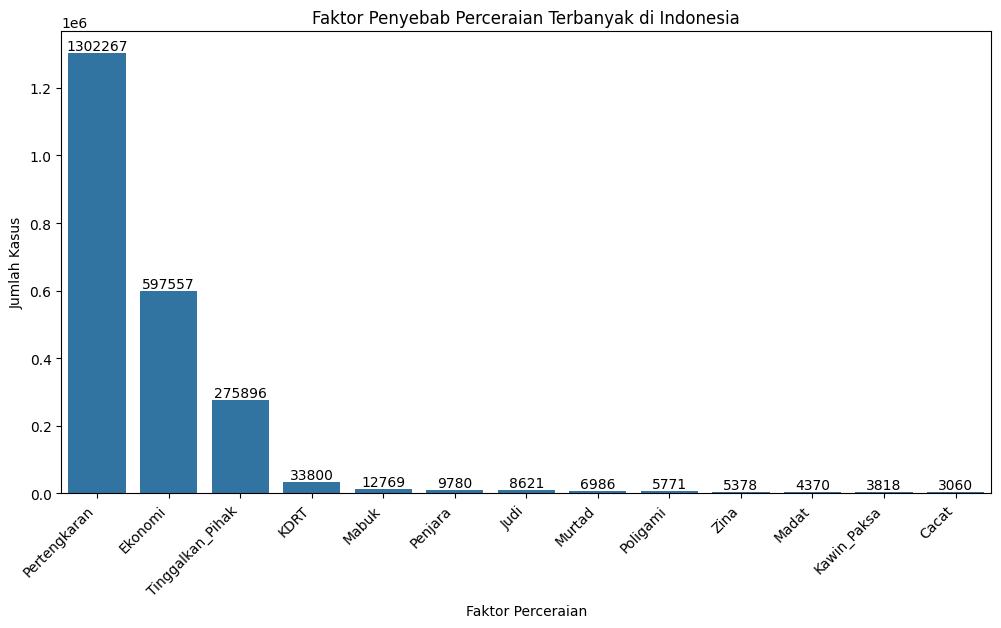

In [ ]:
# Menghitung jumlah faktor perceraian, menghapus kolom 'Provinsi'
faktor_cerai = data_filter.drop(columns=['Provinsi']).sum().sort_values(ascending=False)

# Membuat grafik batang
plt.figure(figsize=(12, 6))
sns.barplot(x=faktor_cerai.index, y=faktor_cerai.values)

# Menambahkan judul dan label
plt.title('Faktor Penyebab Perceraian Terbanyak di Indonesia')
plt.xlabel('Faktor Perceraian')
plt.ylabel('Jumlah Kasus')

# Menampilkan angka di atas batang
for i, value in enumerate(faktor_cerai.values):
    plt.text(i, value + 10, str(int(value)), ha='center', va='bottom', fontsize=10)  # Menambahkan angka dengan sedikit jarak dari batang

# Mengatur tampilan sumbu X agar lebih mudah dibaca
plt.xticks(rotation=45, ha='right')

# Menampilkan plot
plt.show()

**Visualisasi Heatmap**

Visualisasi ini menunjukkan korelasi antara berbagai faktor yang mempengaruhi perceraian. Nilai korelasi berkisar dari -1 hingga 1.
1.   **Nilai mendekati 1** menunjukkan korelasi positif yang kuat, artinya kedua faktor cenderung meningkat bersama-sama.
2.   **Nilai mendekati -1** menunjukkan korelasi negatif yang kuat, artinya jika satu faktor meningkat, yang lain cenderung menurun.



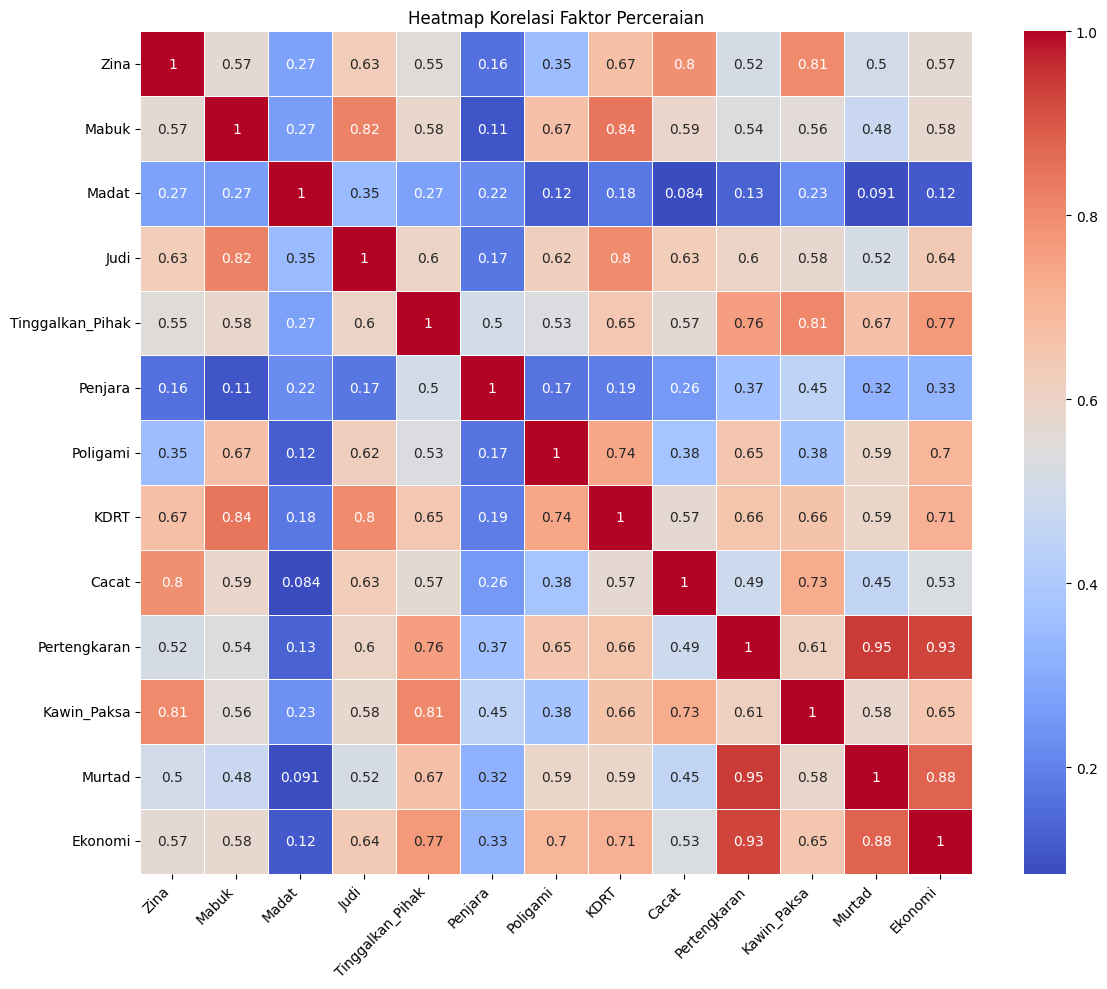

In [ ]:
# Calculate correlation matrix, excluding non-numeric columns
correlation_matrix = data_filter.drop(columns=['Provinsi']).corr()

plt.figure(figsize=(12, 10))  # Mengatur ukuran heatmap
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', linewidths=.5)
plt.title('Heatmap Korelasi Faktor Perceraian')
plt.xticks(rotation=45, ha='right')  # Rotasi label sumbu x agar terbaca
plt.yticks(rotation=0)  # Rotasi label sumbu y agar terbaca
plt.tight_layout()
plt.show()


## **Model Linear Regression dan Support Vector Regression**



1.   Linear Regression digunakan untuk memprediksi jumlah perceraian yang diharapkan dapat membantu meminimalisir peningkatan kasus perceraian. Regresi linier merupakan salah satu metode dalam *data mining*, di mana teknik ini merupakan metode statistik yang digunakan untuk mengukur sejauh mana hubungan sebab-akibat antara variabel penyebab (*X*) dan variabel akibat (*Y*). Variabel penyebab biasanya disebut sebagai *predictor* (X), sedangkan variabel akibat disebut sebagai *response* atau variabel target (Y).

2.   Support Vector Regression (SVR) adalah turunan dari Support Vector Machine (SVM) yang digunakan dalam konteks regresi. Dalam kasus prediksi jumlah perceraian, SVR bertujuan untuk memberikan hasil prediksi yang akurat dengan mengatasi berbagai tantangan dalam analisis data regresi. Berbeda dengan SVM yang biasanya menghasilkan nilai kategorikal dalam kasus klasifikasi, SVR difokuskan pada penyelesaian kasus regresi dengan output berupa bilangan riil. Metode ini dapat digunakan untuk memprediksi jumlah perceraian berdasarkan variabel-variabel penyebab, seperti data jumlah perceraian pada bulan sebelumnya, faktor ekonomi, sosial, atau lainnya.


In [ ]:
# library membagi data tran dan test
from sklearn.model_selection import train_test_split
# library normalisasi data
from sklearn.preprocessing import StandardScaler
# import model SVR dan Linear Regression  berganda
from sklearn.svm import SVR
from sklearn.linear_model import LinearRegression
# MAE untuk mengukur rata-rata kesalahan absolut antara nilai prediksi dan nilai sebenarnya.
# MSE untuk mengukur rata-rata kesalahan kuadrat  antara nilai prediksi dan nilai sebenarnya.
# R2 mengukur seberapa baik model menjelaskan variasi data sebenarnya.
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt

In [ ]:
# Langkah 1: Membaca dataset
file_path = '/content/drive/My Drive/Colab Notebooks/tutorial/bigdata/forecasting/data_percerai_final.xlsx'
data = pd.read_excel(file_path)

# Menampilkan informasi awal tentang dataset
data.info()

# Langkah 2: Eksplorasi dan pra-pemrosesan
# Mengidentifikasi apakah ada nilai kosong
missing_values = data.isnull().sum()

# Menampilkan beberapa baris pertama
data.head(), missing_values

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 136 entries, 0 to 135
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Provinsi          136 non-null    object 
 1   Zina              136 non-null    float64
 2   Mabuk             136 non-null    float64
 3   Madat             136 non-null    float64
 4   Judi              136 non-null    float64
 5   Tinggalkan_Pihak  136 non-null    object 
 6   Penjara           136 non-null    float64
 7   Poligami          136 non-null    float64
 8   KDRT              136 non-null    float64
 9   Cacat             136 non-null    float64
 10  Pertengkaran      136 non-null    float64
 11  Kawin_Paksa       136 non-null    object 
 12  Murtad            136 non-null    float64
 13  Ekonomi           136 non-null    object 
dtypes: float64(10), object(4)
memory usage: 15.0+ KB


(         Provinsi   Zina  Mabuk  Madat   Judi Tinggalkan_Pihak  Penjara  \
 0            Aceh    1.0   15.0   19.0   10.0            968.0     44.0   
 1  Sumatera Utara  209.0  198.0  508.0  194.0           2551.0    109.0   
 2  Sumatera Barat   12.0    9.0    7.0   44.0           1428.0     35.0   
 3            Riau   24.0   62.0   17.0   58.0           1676.0     50.0   
 4           Jambi    4.0   34.0    8.0   29.0            711.0     29.0   
 
    Poligami   KDRT  Cacat  Pertengkaran Kawin_Paksa  Murtad Ekonomi  
 0      17.0  107.0    8.0        3426.0         1.0     2.0   485.0  
 1       7.0  159.0    4.0        7235.0        10.0    21.0  1623.0  
 2      18.0  147.0   20.0        4868.0        15.0     5.0   735.0  
 3      16.0  208.0   32.0        6926.0        21.0    18.0  1516.0  
 4       9.0  102.0    3.0        2874.0         1.0     3.0   462.0  ,
 Provinsi            0
 Zina                0
 Mabuk               0
 Madat               0
 Judi                0


In [ ]:
# Langkah 2.1: Konversi kolom bertipe objek menjadi numerik
# Mengubah kolom dengan tipe objek menjadi numerik jika memungkinkan
data['Tinggalkan_Pihak'] = pd.to_numeric(data['Tinggalkan_Pihak'], errors='coerce')
data['Kawin_Paksa'] = pd.to_numeric(data['Kawin_Paksa'], errors='coerce')
data['Ekonomi'] = pd.to_numeric(data['Ekonomi'], errors='coerce')

# Verifikasi apakah semua kolom sudah numerik
data.info()

# Langkah 3: Memisahkan fitur (X) dan target (y)
# Misalnya, kita akan memprediksi kolom 'Pertengkaran'
X = data.drop(columns=['Provinsi', 'Pertengkaran'])
y = data['Pertengkaran']

# Membagi dataset menjadi data training dan testing (80:20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Penskalaan data (khusus untuk SVR)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Menampilkan hasil sekilas dari data yang sudah diproses
X_train_scaled[:5], y_train[:5]


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 136 entries, 0 to 135
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Provinsi          136 non-null    object 
 1   Zina              136 non-null    float64
 2   Mabuk             136 non-null    float64
 3   Madat             136 non-null    float64
 4   Judi              136 non-null    float64
 5   Tinggalkan_Pihak  131 non-null    float64
 6   Penjara           136 non-null    float64
 7   Poligami          136 non-null    float64
 8   KDRT              136 non-null    float64
 9   Cacat             136 non-null    float64
 10  Pertengkaran      136 non-null    float64
 11  Kawin_Paksa       128 non-null    float64
 12  Murtad            136 non-null    float64
 13  Ekonomi           131 non-null    float64
dtypes: float64(13), object(1)
memory usage: 15.0+ KB


(array([[ 0.24068901,  3.67888064,  0.59621362,  2.45425017,  3.5613729 ,
         -0.04520554,  4.47264759,  3.78765292, -0.16671854,  0.20962007,
          0.41322379,  3.4026026 ],
        [-0.40394482, -0.9160985 , -0.2704296 , -0.70630525, -0.40666688,
          0.07126659, -0.45151512, -0.46465031,  0.10761644, -0.39958215,
         -0.6697023 , -0.42723557],
        [-0.40394482, -0.29049101, -0.56508829, -0.78875452, -0.46120101,
         -0.2826295 , -0.76056299, -0.28475711, -0.4909326 ,  0.03583712,
         -0.35581068, -0.4450898 ],
        [-0.36427504, -0.47385872, -0.53042256, -0.6925637 , -0.59651383,
         -0.21095434, -0.7399598 , -0.48946317, -0.54081169, -0.43164542,
         -0.77956437, -0.42334965],
        [-0.07131376,  0.36413172, -0.11703375,  0.08355877,         nan,
          0.08380974,  0.47130182,  0.25058027,  0.12482472,         nan,
          0.75520871,         nan]]),
 11     29208.00
 68      5238.00
 129     2858.00
 76      1882.00
 84     18

In [ ]:
# Langkah 2.2: Mengisi nilai kosong dengan median
X_train_df = pd.DataFrame(X_train, columns=X.columns)  # Mengembalikan X_train ke DataFrame untuk pengisian yang mudah
X_test_df = pd.DataFrame(X_test, columns=X.columns)

# Mengisi nilai kosong pada data training dan testing
X_train_df.fillna(X_train_df.median(), inplace=True)
X_test_df.fillna(X_train_df.median(), inplace=True)  # Menggunakan median dari training untuk konsistensi

# Update kembali ke array dan skalakan ulang setelah mengisi nilai kosong
X_train_scaled = scaler.fit_transform(X_train_df)
X_test_scaled = scaler.transform(X_test_df)

# Langkah 4: Implementasi model SVR
svr_model = SVR(kernel='rbf')
svr_model.fit(X_train_scaled, y_train)
y_pred_svr = svr_model.predict(X_test_scaled)

# Langkah 4: Implementasi model Linear Regression
lr_model = LinearRegression()
lr_model.fit(X_train_df, y_train)  # Menggunakan data tanpa penskalaan untuk Linear Regression
y_pred_lr = lr_model.predict(X_test_df)

# Langkah 5: Evaluasi model
metrics = {
    "MAE": (mean_absolute_error(y_test, y_pred_svr), mean_absolute_error(y_test, y_pred_lr)),
    "MSE": (mean_squared_error(y_test, y_pred_svr), mean_squared_error(y_test, y_pred_lr)),
    "R2": (r2_score(y_test, y_pred_svr), r2_score(y_test, y_pred_lr))
}
metrics



{'MAE': (5468.089781677665, 2087.5695717787094),
 'MSE': (68880956.62489285, 12622084.985262414),
 'R2': (-0.06193129901798633, 0.8054064902479715)}

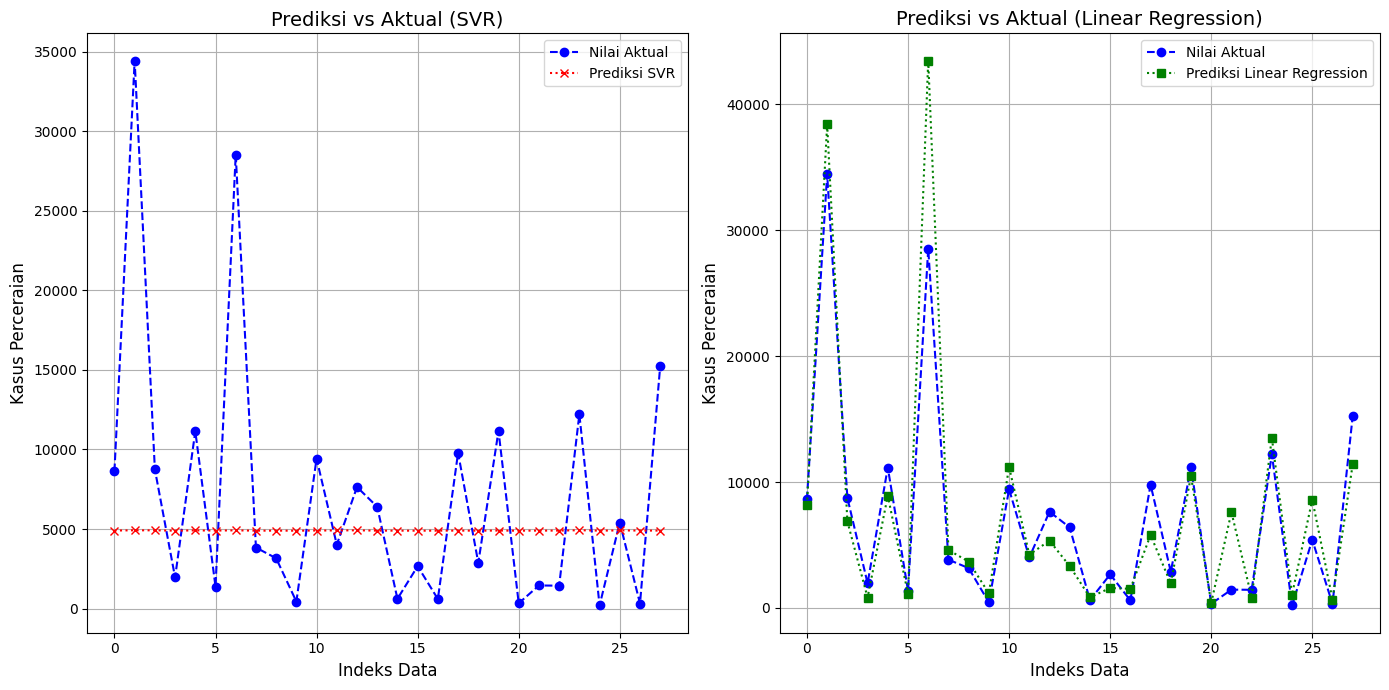

In [ ]:
# Langkah 6: Visualisasi hasil prediksi vs nilai aktual

plt.figure(figsize=(14, 7))

# Plot untuk SVR
plt.subplot(1, 2, 1)
plt.plot(y_test.values, label='Nilai Aktual', color='blue', marker='o', linestyle='dashed')
plt.plot(y_pred_svr, label='Prediksi SVR', color='red', marker='x', linestyle='dotted')
plt.title('Prediksi vs Aktual (SVR)', fontsize=14)
plt.xlabel('Indeks Data', fontsize=12)
plt.ylabel('Kasus Perceraian', fontsize=12)
plt.legend()
plt.grid(True)

# Plot untuk Linear Regression
plt.subplot(1, 2, 2)
plt.plot(y_test.values, label='Nilai Aktual', color='blue', marker='o', linestyle='dashed')
plt.plot(y_pred_lr, label='Prediksi Linear Regression', color='green', marker='s', linestyle='dotted')
plt.title('Prediksi vs Aktual (Linear Regression)', fontsize=14)
plt.xlabel('Indeks Data', fontsize=12)
plt.ylabel('Kasus Perceraian', fontsize=12)
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()
